# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Creating directory: output/draft3_run//alpha_search...Directory exists. Skipping.
Number of alphas: 3
Testing alpha values: [24, 32, 36]
Running for genes: ['DSE1', 'DSE2']
Searching replicate 1 alphas: DSE1...
24,32,36,
00:02:12.820
Searching replicate 1 alphas: DSE2...
24,32,36,
00:04:33.844
Searching replicate 2 alphas: DSE1...
24,32,36,
00:06:42.794
Searching replicate 2 alphas: DSE2...
24,32,36,
00:08:49.692
Results saved to output/draft3_run//alpha_search


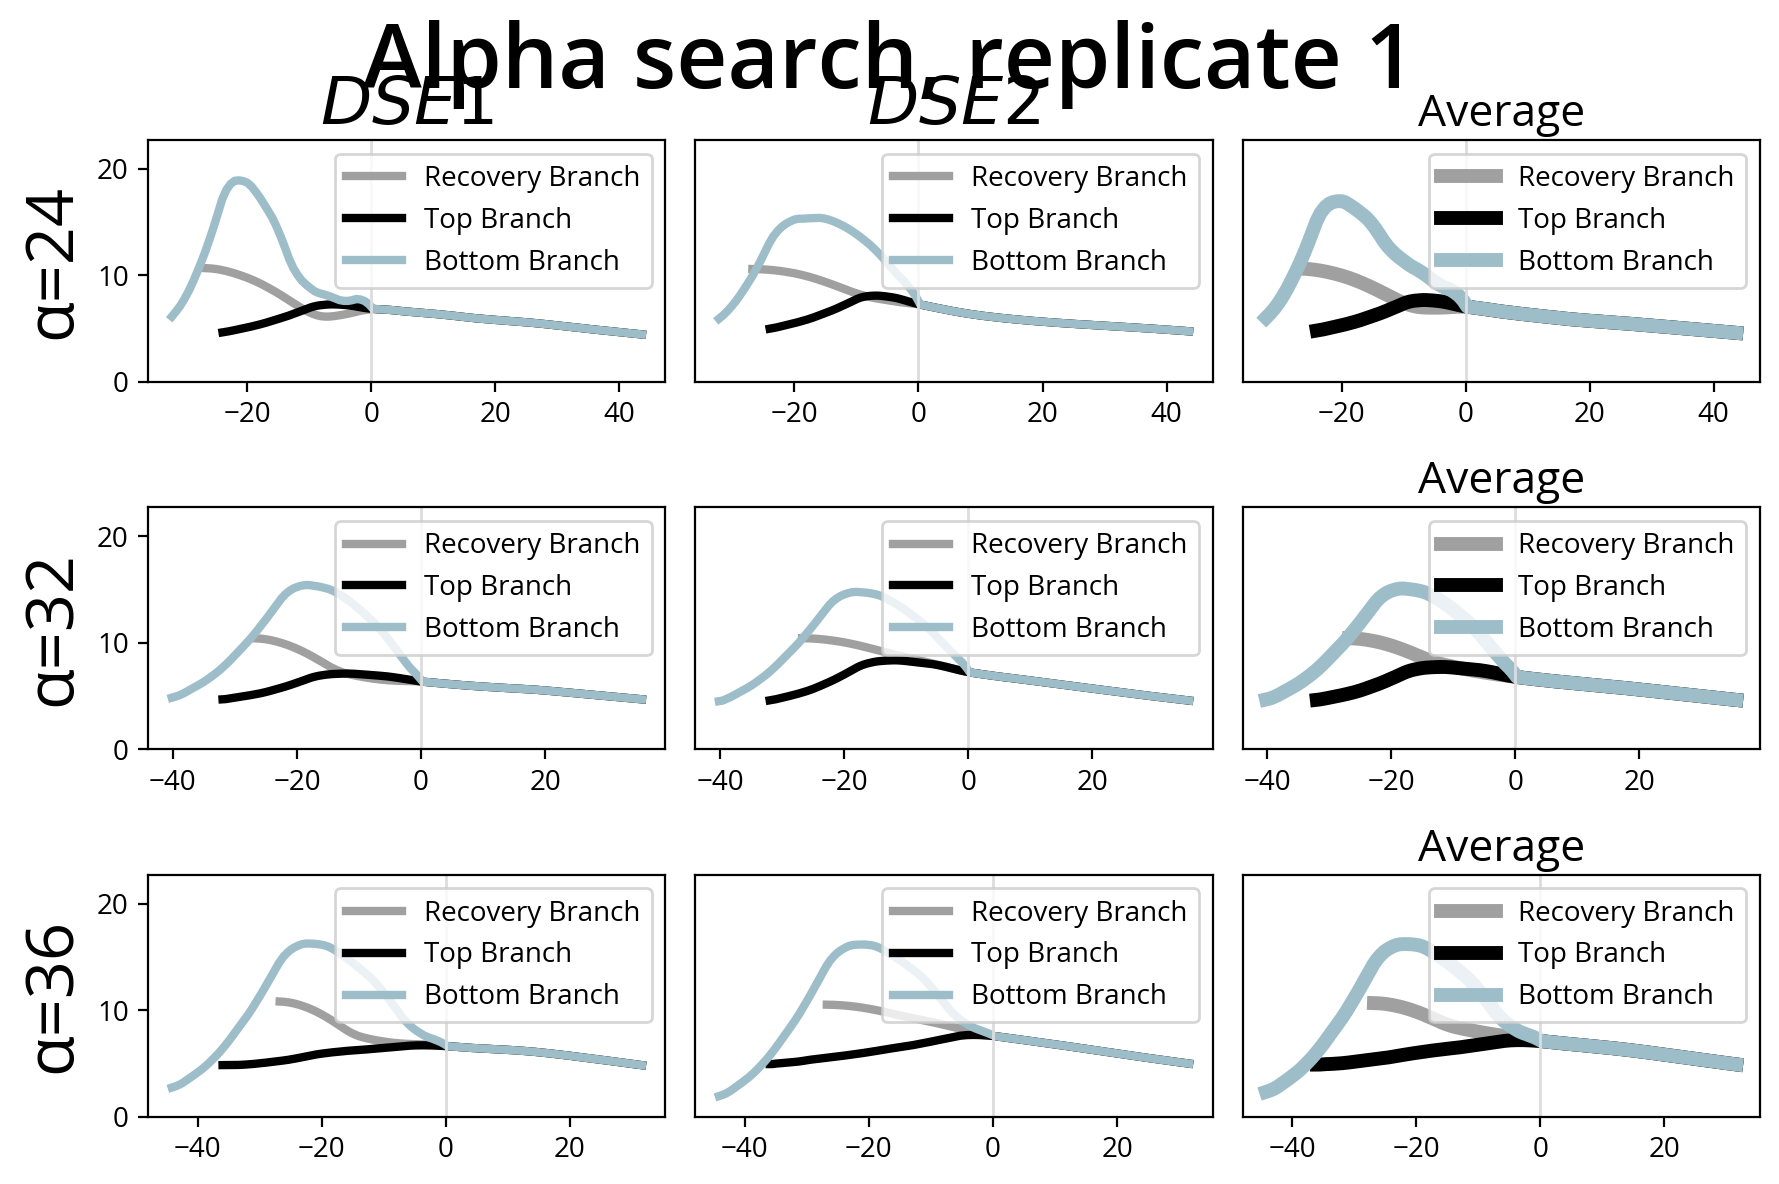

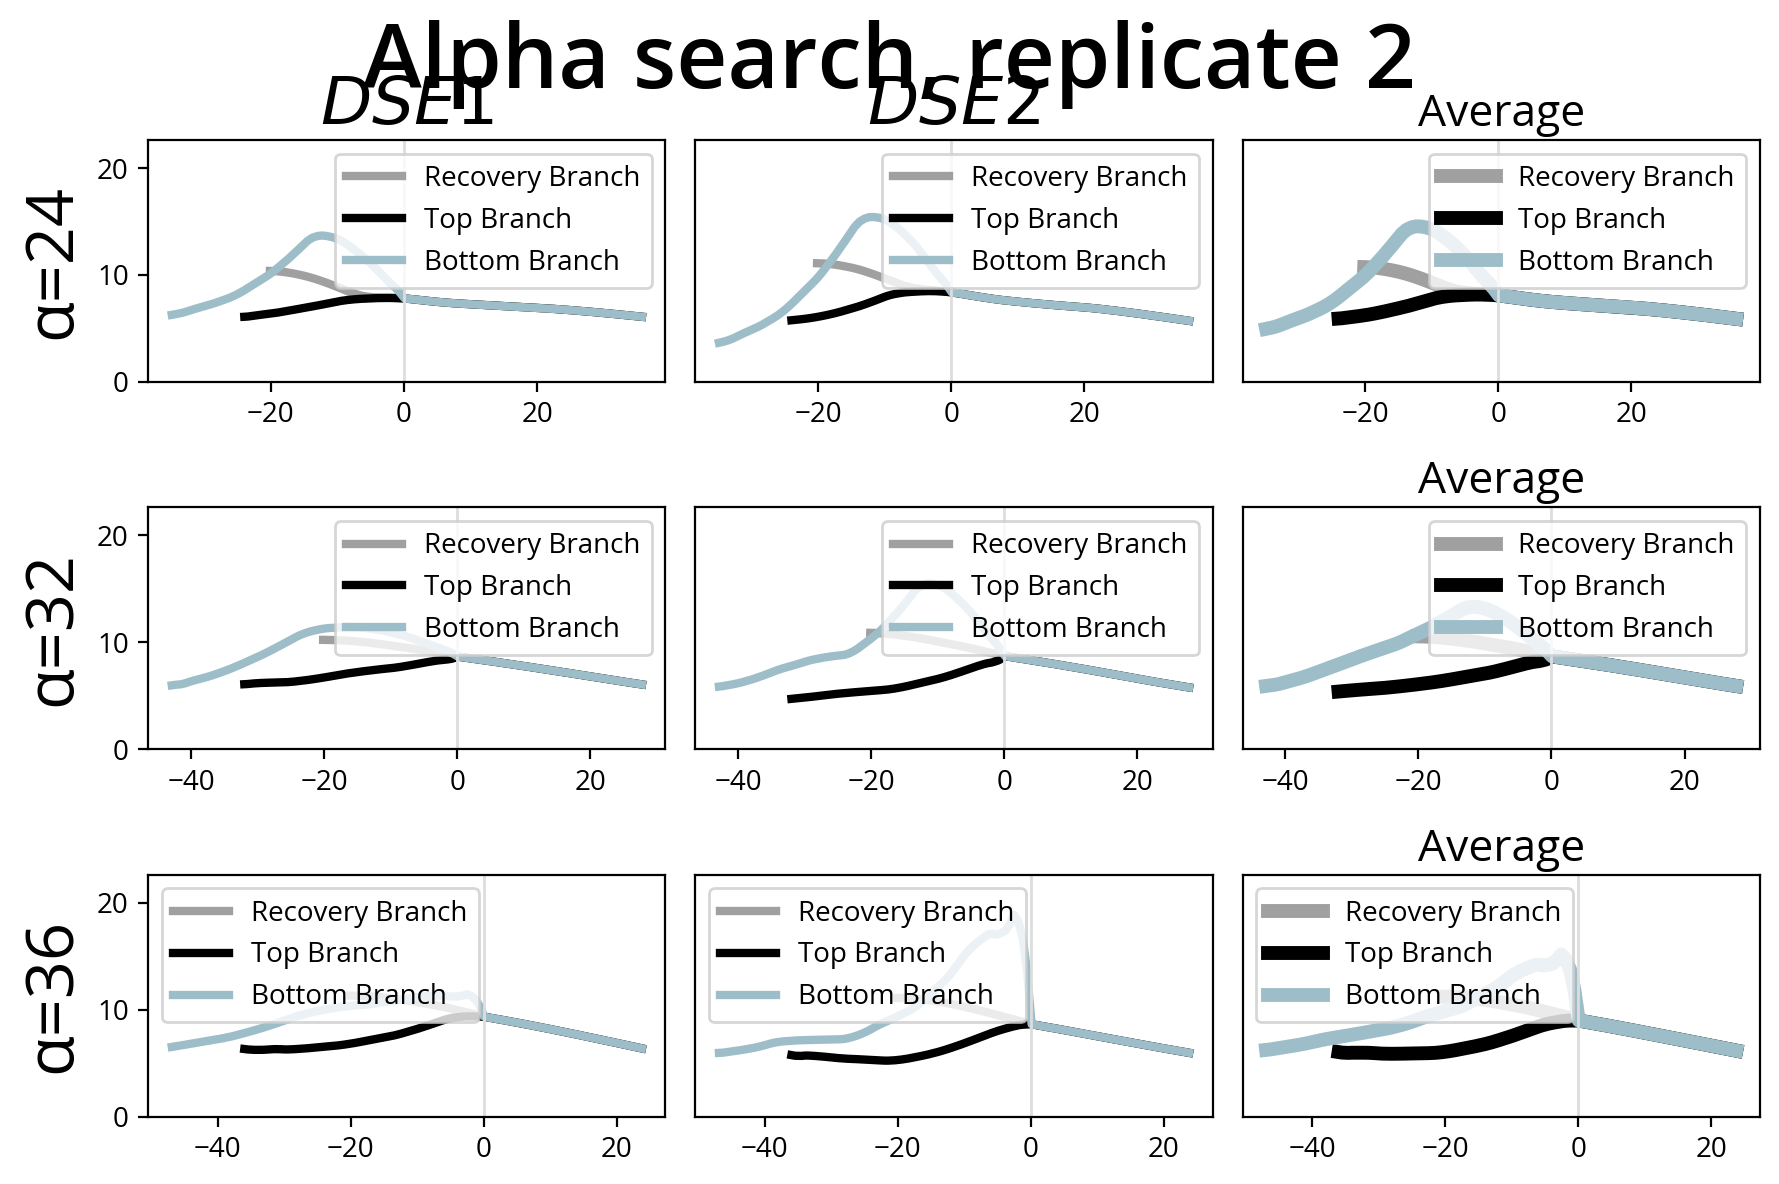

In [2117]:
from src.alpha_search import FindAlphaSweepDS

finder = FindAlphaSweepDS(output_directory='output/draft3_run/', 
    gene_names=['DSE1', 'DSE2'])
finder.run_alpha_sweep(alphas=[24, 32, 36])
finder.plot_and_save_results(save=False)


In [2259]:
finder.runner.config1.modify_alpha(20)
finder.runner.deconvolve_gene_find_gamma('DSE3', replicate=1, verbose=True)

	Base error (γ=0):	rn: 0.359608	sn: 9138.686769
	Error boundaries:
		Left:
			Relative (1.05 * e0): 0.377588
			Absolute (e0 + 0.04): 0.399608
			Chosen: 0.377588
		Right:
			Relative (4.00 * e0): 1.43843
			Absolute (e0 + 11.32): 11.6796
			Chosen: 11.679608
	Searching for left boundary gamma...
		γ: 0.5005	rn: 30.3684	sn: 56.8300
		γ: 0.25075	rn: 21.5425	sn: 86.5765
		γ: 0.125875	rn: 7.4679	sn: 163.9670
		γ: 0.0634375	rn: 2.9536	sn: 212.0839
		γ: 0.0322187	rn: 1.6982	sn: 238.4699
		γ: 0.0166094	rn: 1.3756	sn: 251.8777
		γ: 0.00880469	rn: 1.2834	sn: 259.1570
		γ: 0.00490234	rn: 1.2453	sn: 264.6547
		γ: 0.00295117	rn: 1.2331	sn: 267.8572
		γ: 0.00197559	rn: 1.1801	sn: 293.2753
		γ: 0.00148779	rn: 0.9830	sn: 410.4347
		γ: 0.0012439	rn: 0.9164	sn: 459.0261
		γ: 0.00112195	rn: 0.8963	sn: 475.7014
		γ: 0.00106097	rn: 0.8829	sn: 487.9604
		γ: 0.00103049	rn: 0.8759	sn: 494.6057
		γ: 0.00101524	rn: 0.8751	sn: 495.3411
		γ: 0.00100762	rn: 0.8746	sn: 495.8558
		γ: 0.00100381	rn: 0.8746	sn: 495.

In [2260]:
finder.runner.expression_find_gamma.gamma_optimizer.gamma_left,\
finder.runner.expression_find_gamma.gamma_optimizer.gamma_right

(0.0010004763603210448, 0.1665808631990119)

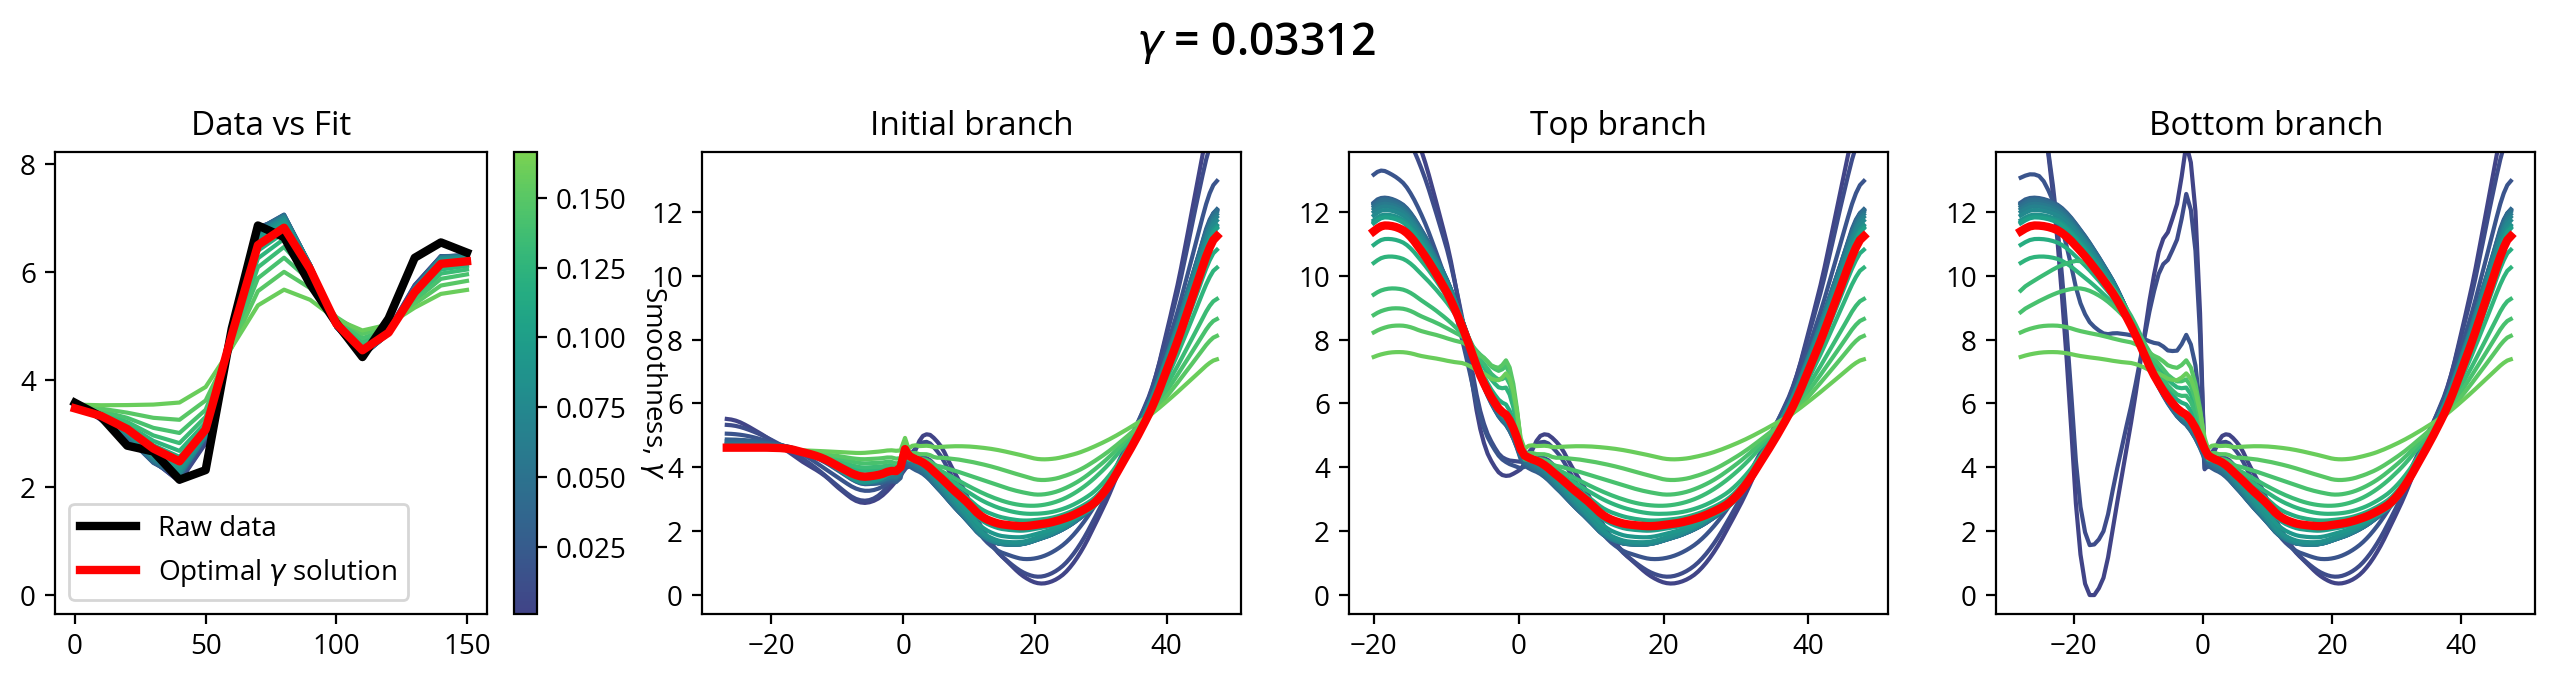

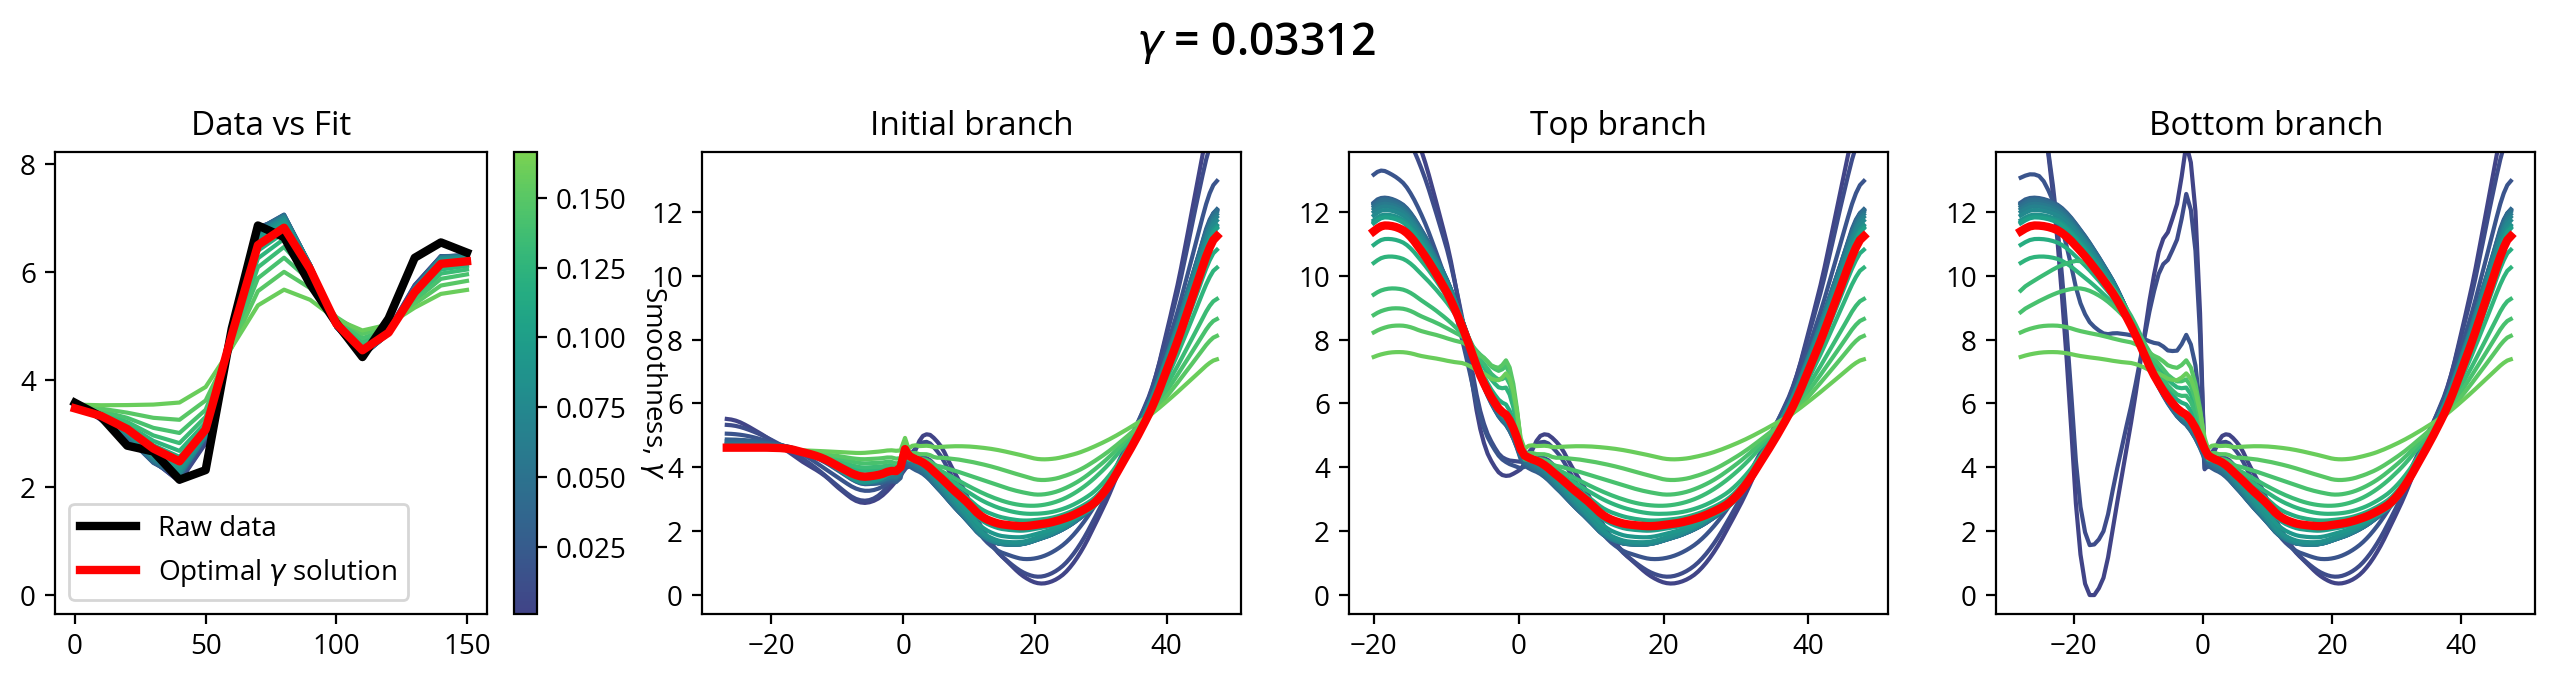

In [2261]:
finder.runner.expression_find_gamma.plot_gamma_sweep()

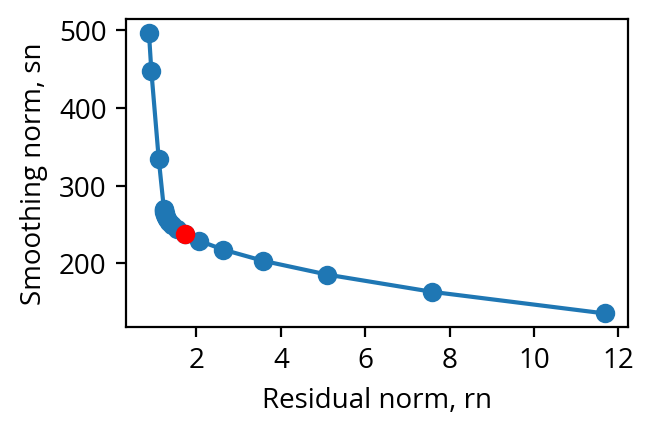

In [2262]:
finder.runner.expression_find_gamma.gamma_optimizer.plot_elbow()

In [2263]:
finder.runner.expression_find_gamma.deconvolution_solver.gamma = 0.03
finder.runner.expression_find_gamma.deconvolution_solver.deconvolve()

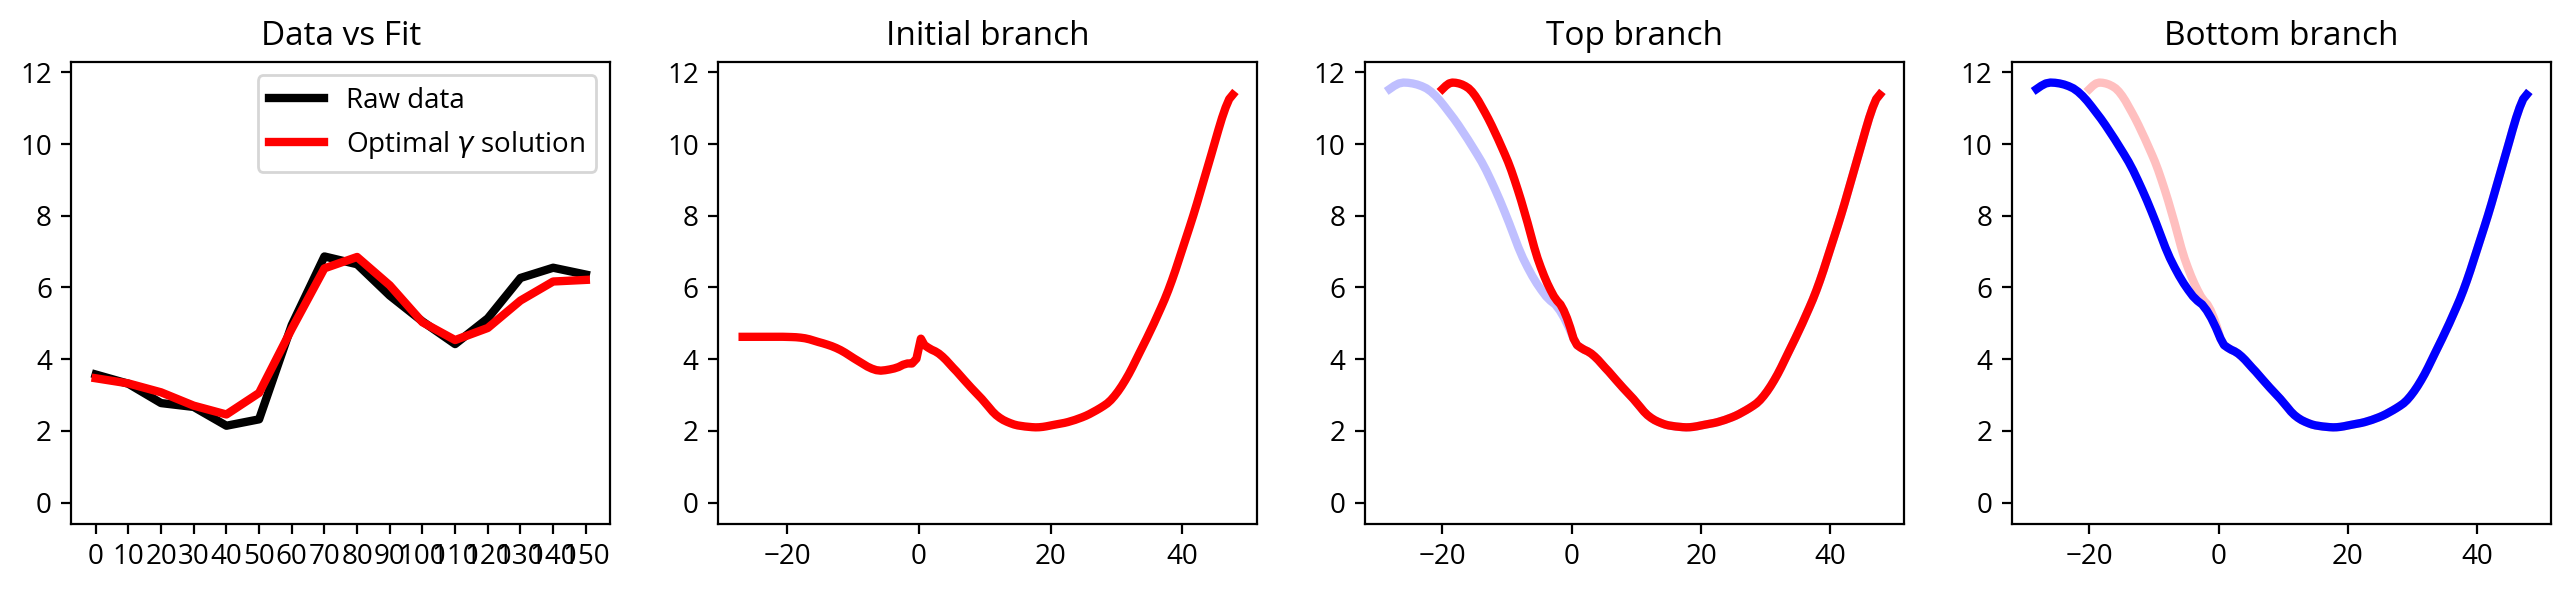

In [2264]:
finder.runner.expression_find_gamma.deconvolution_solver.plot_fit(True)